## HD5750 

Spectral analysis of HD5750 from the fits data and interpolator flux predicted values 

In [74]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from astropy.io import fits

In [75]:
path_5750 = "../FITS_data/5750.fits"

In [76]:
with fits.open(path_5750) as data_5750:
    data_5750.info()


Filename: ../FITS_data/5750.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     107   (15011,)   float32   
  1  c0101110027    1 ImageHDU       143   (3062, 1, 4)   float32   
  2  c0210160091    1 ImageHDU       143   (3059, 1, 4)   float32   
  3  c0210210034    1 ImageHDU       143   (3059, 1, 4)   float32   
  4  c0210240032    1 ImageHDU       143   (3059, 1, 4)   float32   
  5  a0101110027    1 ImageHDU       107   (3062, 1, 4)   float32   
  6  a0210160091    1 ImageHDU       107   (3059, 1, 4)   float32   
  7  a0210210034    1 ImageHDU       107   (3059, 1, 4)   float32   
  8  a0210240032    1 ImageHDU       107   (3059, 1, 4)   float32   


In [77]:
data_5750 = fits.open(path_5750)

In [78]:
hdr = data_5750[0].header

crval = hdr["CRVAL1"]      # start value of the wavelength pixel
cdelt = hdr["CDELT1"]      # step value of the wavelength pixel

print(cdelt)

0.4


In [79]:
n_wave_points = len(data_5750[0].data)
n_wave_points

15011

In [80]:
wavelengths = crval + cdelt * np.arange(n_wave_points)

flux = data_5750[0].data

flux

array([7.477026e-01, 7.218224e-01, 6.585574e-01, ..., 1.000000e-04,
       1.000000e-04, 1.000000e-04], dtype=float32)

Plotting the flux-wavelength continuum for HD5750:

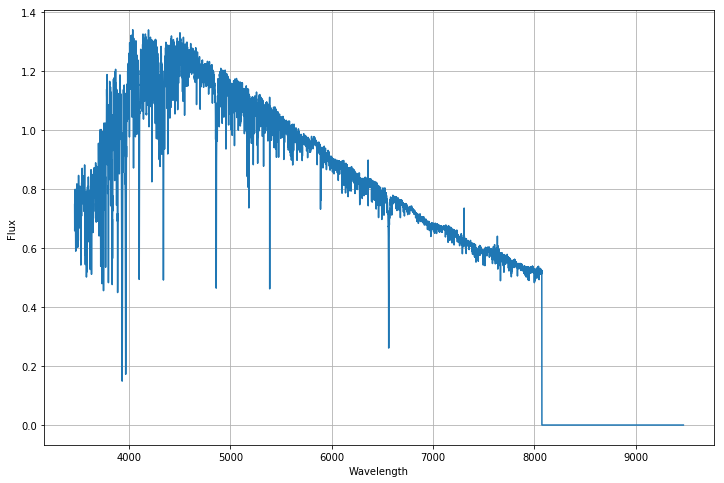

In [81]:
plt.figure(figsize = (12, 8))
plt.plot(wavelengths,flux)
plt.xlabel("Wavelength")
plt.ylabel("Flux")
plt.grid()
plt.show()

Plotting the wavelength - flux continuum for HD5750 using the interpolator pipeline : 

In [82]:
from sklearn.externals import joblib

In [83]:
INTERPOLATOR_MODEL = 'RF_base_model_pvk.sav'
STANDARD_SCALER = 'rf_standard_scale_pvk.sav'

In [84]:
from sklearn.externals import joblib

sc = joblib.load(STANDARD_SCALER)
ip = joblib.load(INTERPOLATOR_MODEL)

In [85]:
ip.n_jobs = 1 

def InterpolateSpectrum(temperature, gravity, metallicity):
    X = np.array([temperature, gravity, metallicity]).reshape(1, -1)
    X_std = sc.transform(X)
    y = ip.predict(X_std)
    return y

In [86]:
pred = InterpolateSpectrum(6330,4.21,-0.42)

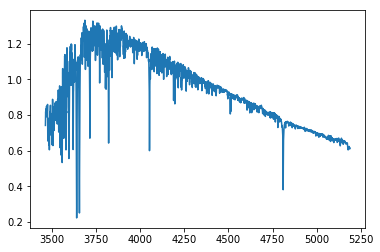

In [87]:
plt.plot(wavelengths[:4306],pred[0,:])

#### Comparing the Interpolator flux curve and CFLIB Fits flux curve : 

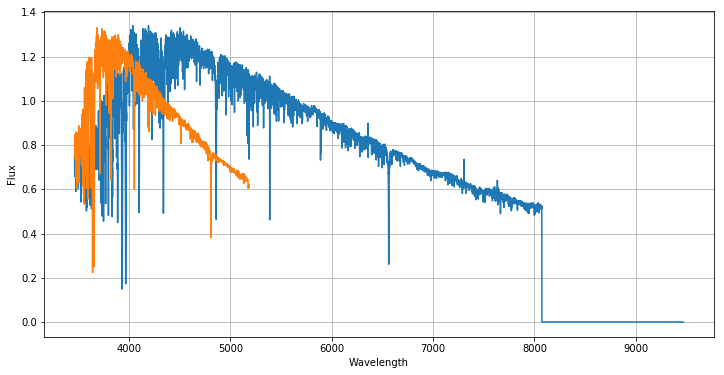

In [91]:
plt.figure(figsize = (12,6))
plt.plot(wavelengths, flux)
plt.plot(wavelengths[:4306], pred[0,:])
plt.xlabel("Wavelength")
plt.ylabel("Flux")
plt.grid()
plt.show()

#### Limiting to just 4306 values (number of values predicted by the interpolator pipeline)

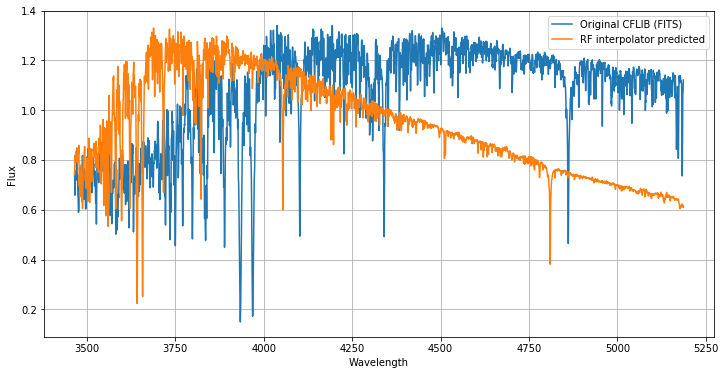

In [92]:
plt.figure(figsize = (12,6))
plt.plot(wavelengths[:4306], flux[:4306], label = "Original CFLIB (FITS)")
plt.plot(wavelengths[:4306], pred[0,:], label = "RF interpolator predicted")
plt.xlabel("Wavelength")
plt.ylabel("Flux")
plt.legend()
plt.grid()
plt.show()